In [3]:
import yfinance as yf

data = yf.download("AAPL",start='2015-01-01',end='2024-01-01')

print(data.head())

[*********************100%***********************]  1 of 1 completed

Price           Close       High        Low       Open     Volume
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL
Date                                                             
2015-01-02  24.237547  24.705316  23.798597  24.694231  212818400
2015-01-05  23.554743  24.086803  23.368523  24.006994  257142000
2015-01-06  23.556952  23.816330  23.195593  23.619025  263188400
2015-01-07  23.887281  23.987042  23.654504  23.765350  160423600
2015-01-08  24.805088  24.862728  24.097891  24.215389  237458000


In [4]:
import torch 
import torch.nn as nn 
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt 

from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import Dataset , DataLoader

In [5]:
data = yf.download("AAPL",start='2015-01-01', end='2024-01-01')

prices = data["Close"].values.reshape(-1,1)

print("Total data points:", len(prices))

[*********************100%***********************]  1 of 1 completed

Total data points: 2264


In [6]:
scaler = MinMaxScaler(feature_range=(0,1))

prices_scaled = scaler.fit_transform(prices)

In [11]:
def create_sequences(data, seq_length):

    X = []
    Y = []

    for i in range(seq_length, len(data)):

        X.append(data[i - seq_length : i])

        Y.append(data[i])

    return np.array(X), np.array(Y)

In [12]:
seq_length = 60

X,Y = create_sequences(prices_scaled, seq_length)

print("X shape", X.shape)
print("Y shape", Y.shape)

X shape (2204, 60, 1)
Y shape (2204, 1)


In [14]:
train_size = int(0.8* len(X))

X_train = X[:train_size]
X_test  = X[train_size:]

Y_train = Y[:train_size]
Y_test  = Y[train_size:]

In [16]:
X_train = torch.FloatTensor(X_train)
Y_train = torch.FloatTensor(Y_train)

X_test = torch.FloatTensor(X_test)
Y_test = torch.FloatTensor(Y_test)

In [17]:
class StockDataset(Dataset):

    def __init__(self,X,Y):

        self.X = X
        self.Y = Y

    def __len__(self):

        return len(self.X)

    def __getitem__(self,idx):

        return self.X[idx], self.Y[idx]



In [20]:
train_dataset = StockDataset(X_train, Y_train)

test_dataset =StockDataset(X_test,Y_test)

train_loader = DataLoader(train_dataset, batch_size=32 , shuffle=True)

test_loader = DataLoader(test_dataset,batch_size=32)


In [24]:
class LSTMModel(nn.Module):

    def __init__(self):

        super(LSTMModel,self).__init__()

        self.lstm = nn.LSTM(
            input_size = 1,
            hidden_size=64,
            num_layers=2,
            batch_first=True
        )

        self.fc = nn.Linear(64,1)

    def forward(self,x):

        out, _ = self.lstm(x)

        out = out[:,-1,:]

        out = self.fc(out)

        return out

In [27]:
model = LSTMModel()

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(model.parameters(), lr = 0.001)



In [33]:
epochs = 20



for epoch in range(epochs):

    total_loss = 0

    for X_batch, Y_batch in train_loader:

        output = model(X_batch)

        loss = criterion(output, Y_batch)

        loss.backward()

        optimizer.step()

        optimizer.zero_grad()

        total_loss += loss.item()

    print(f"Epoch {epoch + 1}/{epochs}, Loss: {total_loss / len(train_loader)}")

Epoch 1/20, Loss: 8.649083857140536e-05
Epoch 2/20, Loss: 8.613717162526362e-05
Epoch 3/20, Loss: 7.761639098394621e-05
Epoch 4/20, Loss: 8.029111544211836e-05
Epoch 5/20, Loss: 8.145173845670277e-05
Epoch 6/20, Loss: 8.036474248131396e-05
Epoch 7/20, Loss: 8.510446683171072e-05
Epoch 8/20, Loss: 7.678457088137034e-05
Epoch 9/20, Loss: 7.785390809138854e-05
Epoch 10/20, Loss: 8.340069111259904e-05
Epoch 11/20, Loss: 9.792959248703223e-05
Epoch 12/20, Loss: 7.770125643803892e-05
Epoch 13/20, Loss: 7.396143186204946e-05
Epoch 14/20, Loss: 8.827918366348188e-05
Epoch 15/20, Loss: 8.538627194606565e-05
Epoch 16/20, Loss: 8.70050304878792e-05
Epoch 17/20, Loss: 8.613843780429826e-05
Epoch 18/20, Loss: 0.00012069262818061231
Epoch 19/20, Loss: 8.60767606484712e-05
Epoch 20/20, Loss: 7.507311290412742e-05


In [34]:
model.eval()

predictions = []

with torch.no_grad():

    for X_batch, Y_batch in test_loader:

        output = model(X_batch)

        predictions.append(output.numpy())

predictions = np.concatenate(predictions)



In [36]:
predictions = scaler.inverse_transform(predictions)

real = scaler.inverse_transform(Y_test.numpy())

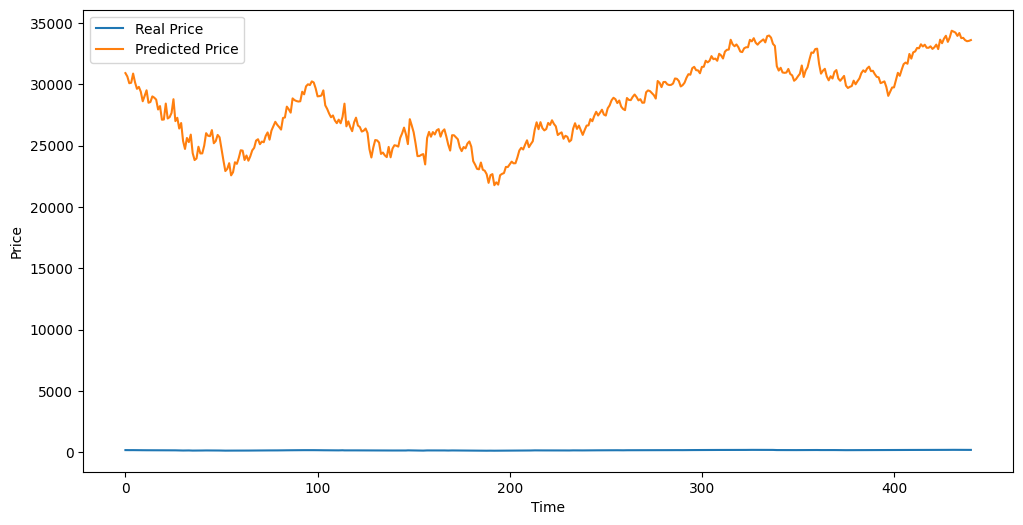

In [37]:
plt.figure(figsize=(12,6))

plt.plot(real, label="Real Price")

plt.plot(predictions, label="Predicted Price")

plt.xlabel("Time")

plt.ylabel("Price")

plt.legend()

plt.show()

In [38]:
last_sequence = prices_scaled[-seq_length:]

last_sequence = torch.FloatTensor(last_sequence).unsqueeze(0)

future_price = model(last_sequence).detach().numpy()

future_price = scaler.inverse_transform(future_price)

print("Next day predicted price:", future_price[0][0])


Next day predicted price: 190.01196
